In [1]:
# LabOne Q:
from laboneq.simple import *

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
import time
import os
import pandas as pd
import laboneq
from datetime import datetime
from laboneq.contrib.example_helpers.plotting.plot_helpers import (
    plot_results,
    plot_simulation,
)
from laboneq.analysis.fitting import oscillatory

print(laboneq.__version__)

2.51.0


In [2]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.26 06:11:01.817] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.26 06:11:01.817] INFO    VERSION: laboneq 2.51.0
[2025.08.26 06:11:01.817] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.26 06:11:01.833] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.26 06:11:01.838] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.26 06:11:01.843] INFO    Configuring the device setup
[2025.08.26 06:11:01.850] INFO    The device setup is configured


In [23]:
res_lo_freq = 7.2e9
qb_lo_freq = 3.4e9
qubit_label = "Q5"  # ch2ange if needed
# qb_freq = 3.10268e9 #Q1
# qb_freq = 3.19586e9 #Q2
# qb_freq = 3.19190e9 #Q3
# qb_freq = 3.37406e9 #Q4
qb_freq =3.37316e9 #Q5
# qb_freq = 3.3990e9 #Q6

# res_freq = 7.14886e9 #Q1
# res_freq = 7.18128e9 #Q2
# res_freq = 7.20643e9 #Q3
# res_freq = 7.23027e9 #Q4
res_freq = 7.26203e9 #Q5
# res_freq = 7.29047e9 #Q6
integration_time = 0.5e-5

amp_min = 0
amp_max = 1
amp_num = 201

ro_pulse_amp = 0.1
ro_pulse_length = 5e-6
drive_pulse_amp = 1
drive_pulse_length = 1e-6
drive_range = -5
num_averages = 11  # average number = 2^n, n_max = 17
measure_range = -20  # actual power = range (dBm) - 20log(amp)
measure_amp = 0.9
acquire_range = -30
acquire_amp = 0.9
integration_time = 0.5e-5


In [24]:
# range of pulse amplitude scan
def create_rabi_amp_sweep(amp_min, amp_max, amp_num, uid="rabi_amp"):
    return LinearSweepParameter(uid=uid, start=amp_min, stop=amp_max, count=amp_num)


def create_readout_pulse(
    qubit, length=ro_pulse_length, amplitude=ro_pulse_amp):
    readout_pulse = pulse_library.const(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude)
    return readout_pulse


def create_rabi_drive_pulse(qubit, length=drive_pulse_length, amplitude=drive_pulse_amp):
    return pulse_library.const(
        uid=f"gaussian_drive_q{qubit}", length=length, amplitude=amplitude
    )

In [25]:
# function that returns an amplitude Rabi experiment


def amplitude_rabi(drive_pulse, readout_pulse, amplitude_sweep):
    exp_rabi = Experiment(
        uid="Amplitude Rabi",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define Rabi experiment pulse sequence
    # outer loop - real-time, cyclic averaging
    with exp_rabi.acquire_loop_rt(
        uid="rabi_shots",
        count=pow(2, num_averages),
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        # inner loop - real time sweep of Rabi ampitudes
        with exp_rabi.sweep(uid="rabi_sweep", parameter=amplitude_sweep):
            # play qubit excitation pulse - pulse amplitude is swept
            with exp_rabi.section(
                uid="qubit_excitation"):
                exp_rabi.play(
                    signal="drive", pulse=drive_pulse, amplitude=amplitude_sweep
                )
            # readout pulse and data acquisition
            with exp_rabi.section(uid="readout_section", play_after="qubit_excitation"):
                # play readout pulse on measure line
                # exp_rabi.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_rabi.measure(
                    measure_signal='measure',
                    measure_pulse=readout_pulse,
                    acquire_signal="acquire",
                    integration_length = integration_time,
                    handle="amp_rabi",
                    reset_delay = 50e-6,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_rabi.section(uid="reserve", length=250e-6):
                exp_rabi.reserve(signal="measure")
    return exp_rabi

In [26]:
# define pulses and create experiment
readout_pulse = create_readout_pulse("q0")
drive_pulse = create_rabi_drive_pulse("q0")
exp_rabi = amplitude_rabi(drive_pulse, readout_pulse, create_rabi_amp_sweep(amp_min, amp_max, amp_num))


# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "drive_line"
        ],
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map


# run the experiment on qubit 0
exp_rabi.set_signal_map(signal_map_default("q0"))

In [27]:
exp_calibration = Calibration()
exp_calibration["drive"] = SignalCalibration(
    oscillator = Oscillator(uid = "ch0_osc_0", frequency = qb_freq -qb_lo_freq, 
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="ch0_lo", frequency = qb_lo_freq),
    range = drive_range,
)
exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = res_freq-res_lo_freq,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = res_lo_freq),
    range = measure_range
)
exp_calibration["acquire"] = SignalCalibration(
    range = acquire_range
)
exp_rabi.set_calibration(exp_calibration)

In [28]:
# compile the experiment on the open instrument session
compiled_rabi = session.compile(exp_rabi)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Rabi", compiled_rabi)

[2025.08.26 06:33:27.170] INFO    Starting LabOne Q Compiler run...
[2025.08.26 06:33:27.215] INFO    Schedule completed. [0.040 s]
[2025.08.26 06:33:27.344] INFO    Code generation completed for all AWGs. [0.134 s]
[2025.08.26 06:33:27.352] INFO    Completed compilation step 1 of 1. [0.177 s]
[2025.08.26 06:33:27.356] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.26 06:33:27.358] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.26 06:33:27.359] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.26 06:33:27.359] INFO      device_shfqc        0         12            0           1     20000  
[2025.08.26 06:33:27.360] INFO      device_shfqc_sg     1        615          202           2      8000  
[2025.08.26 06:33:27.360] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.26 06:33:27.360] INFO      TOTAL                        627 

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Rabi_2025-08-26-06-33-27.html

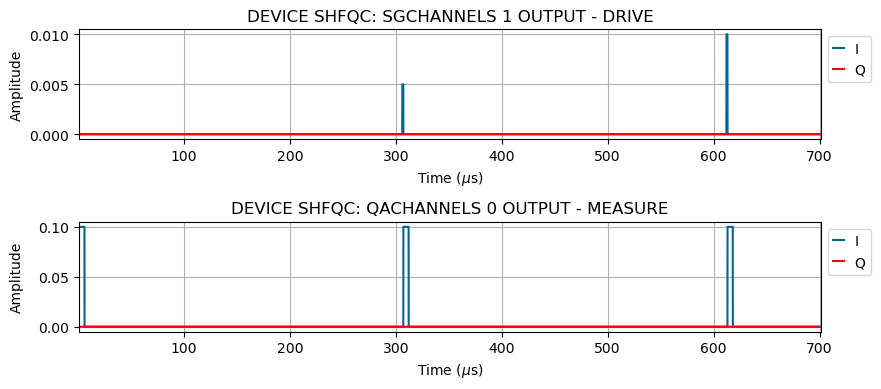

In [29]:
plot_simulation(compiled_rabi, start_time=1e-6, length=700e-6)

In [30]:
# run the compiled experiemnt
rabi_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")

# --- Make output folder + timestamp ---
outdir = "rabi_results"
os.makedirs(outdir, exist_ok=True)


[2025.08.26 06:33:40.275] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.26 06:33:40.280] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.26 06:33:40.285] INFO    Configuring the device setup
[2025.08.26 06:33:40.295] INFO    The device setup is configured
[2025.08.26 06:33:40.634] INFO    Starting near-time execution...
[2025.08.26 06:33:40.679] INFO    Estimated RT execution time: 125.96 s.
[2025.08.26 06:35:46.723] INFO    Finished near-time execution.


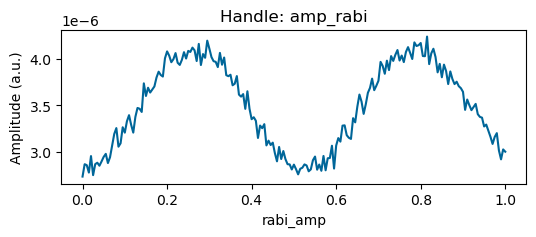

In [31]:
plot_results(rabi_results)

Saved figure to rabi_results\rabi_experiment_Q5_20250826T063546.png
Saved data to rabi_results\rabi_experiment_Q5_20250826T063546Q2.csv


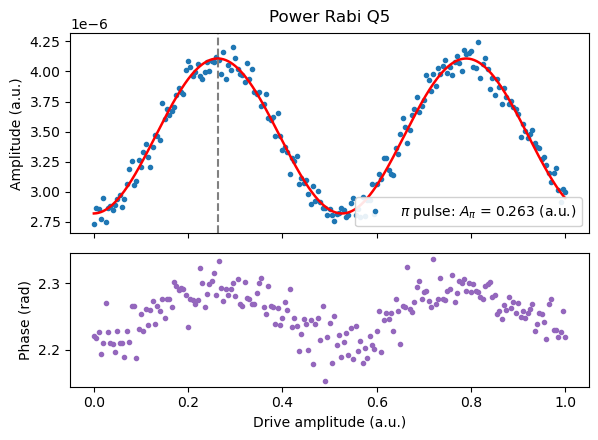

In [32]:
# --- Convert to dBm for the trace (keep your original definition) ---
def to_dbm(signal):
    power_W = (signal**2) / 50.0
    return 10 * np.log10(np.maximum(power_W, 1e-20) / 1e-3)  # avoid log(0)

# --- Data acquisition ---
rabi_res = rabi_results.get_data("amp_rabi")   # complex data
rabi_amp = rabi_results.get_axis("amp_rabi")[0]

# --- Compute quantities ---
amp_abs   = np.abs(rabi_res)                     # <-- use a.u. for fitting/plotting
amp_dbm   = to_dbm(amp_abs)
phase_rad = np.angle(rabi_res)
real_dbm  = to_dbm(np.abs(rabi_res.real))
imag_dbm  = to_dbm(np.abs(rabi_res.imag))

# ==========================
# New fit function: pure cosine (in a.u.)
# ==========================
def rabi_cosine(x, A, f_rabi, phi, C):
    return A * np.cos(2*np.pi*f_rabi*x + phi) + C

# --- Initial guesses (robust but simple) ---
x = np.asarray(rabi_amp, dtype=float)
y = np.asarray(amp_abs,  dtype=float)           # fit in a.u.

# amplitude & offset
A_guess  = 0.5 * (np.nanmax(y) - np.nanmin(y))
C_guess  = np.nanmean(y)
phi_guess = 0.0

# frequency guess via FFT of detrended data (vs. the sweep variable x)
y_detr = y - C_guess
# guard against uneven spacing by interpolating to uniform grid if needed
if np.allclose(np.diff(x), np.diff(x)[0], rtol=1e-3, atol=0):
    dx = np.mean(np.diff(x))
    freqs = np.fft.rfftfreq(len(x), d=dx)
    Yf = np.abs(np.fft.rfft(y_detr))
else:
    # fall back: coarse period guess from peaks, then convert to frequency
    pk, _ = find_peaks(y_detr, distance=max(2, len(x)//20))
    if len(pk) >= 2:
        period_guess = np.median(np.diff(x[pk]))
        freqs = np.array([1.0/max(period_guess, 1e-12)])
        Yf = np.array([1.0])
    else:
        span = np.ptp(x)
        freqs = np.array([1.0/max(span, 1e-6)])   # one cycle across the sweep
        Yf = np.array([1.0])

# choose the strongest nonzero frequency
if np.size(freqs) > 1:
    f_guess = float(freqs[1 + int(np.nanargmax(Yf[1:]))])
else:
    f_guess = float(freqs[0])

p0 = [A_guess, f_guess, phi_guess, C_guess]

# --- Fit (bounded to keep things reasonable) ---
# A can be any real, f_rabi positive, phi free, C free
lower = [-np.inf, 0.0, -2*np.pi, -np.inf]
upper = [ np.inf, np.inf,  2*np.pi,  np.inf]

popt, pcov = curve_fit(rabi_cosine, x, y, p0=p0, bounds=(lower, upper), maxfev=20000)
A_fit, f_fit, phi_fit, C_fit = popt

# --- Compute fitted curve & find first maximum (π-point proxy) ---
x_plot = np.linspace(x.min(), x.max(), 5*len(x))
y_fit  = rabi_cosine(x_plot, *popt)

pk, _ = find_peaks(y_fit, distance=max(2, len(x_plot)//20))
if len(pk) > 0:
    idx_pi = int(pk[0])               # first peak along the sweep
else:
    idx_pi = int(np.argmax(y_fit))    # fallback

A_pi_point = float(x_plot[idx_pi])    # amplitude (a.u.)

# ===================
# PLOTTING (use a.u. on the main trace)
# ===================
fig, axs = plt.subplots(2, 1, figsize=(6, 4.5),
                        sharex=True, gridspec_kw={'height_ratios': [1.5, 1.0]})

# Amplitude (a.u.) + fit
axs[0].plot(rabi_amp, amp_abs, 'o', ms=3, label="data")
axs[0].plot(x_plot, y_fit, '-r', lw=1.8, label="fit")
axs[0].axvline(A_pi_point, color="grey", linestyle="--", linewidth=1.5)
axs[0].set_ylabel("Amplitude (a.u.)")
axs[0].legend([rf"$\pi$ pulse: $A_\pi$ = {A_pi_point:.3f} (a.u.)"],
              loc="lower right", framealpha=0.9)
axs[0].set_title(f"Power Rabi {qubit_label}", fontsize=12, pad=8)

# Phase
axs[1].plot(rabi_amp, phase_rad, 'o', ms=3, color="tab:purple")
axs[1].set_xlabel("Drive amplitude (a.u.)")
axs[1].set_ylabel("Phase (rad)")

plt.tight_layout()

# --- Save figure ---
fig_path = os.path.join(outdir, f"rabi_experiment_{qubit_label}_{timestamp}.png")
plt.savefig(fig_path, dpi=600)
print(f"Saved figure to {fig_path}")

# --- Save data to CSV (kept your existing columns; added Amplitude_AU) ---
df = pd.DataFrame({
    "DriveAmplitude": rabi_amp,
    "Amplitude_AU": amp_abs,                 # new: the a.u. trace actually fit/plotted
    "Amplitude_dBm": amp_dbm,
    "Real_dBm": real_dbm,
    "Imag_dBm": imag_dbm,
    "Phase_rad": phase_rad,
    "Fit_y(AU)": rabi_cosine(rabi_amp, *popt),
})
csv_path = os.path.join(outdir, f"rabi_experiment_{qubit_label}_{timestamp}Q2.csv")
df.to_csv(csv_path, index=False)
print(f"Saved data to {csv_path}")

plt.show()